## Eval ppl on holdout data for different models at the AA level

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
tqdm.pandas()

In [3]:
results_dir = '/scratch/users/stephen.lu/projects/protevo/paper/ctmc_eval'

# peint_df = pd.read_csv(f"{samples_dir}/peint_model_d4.csv")
# peint_650m_df = pd.read_csv(f"{samples_dir}/peint_650m_model_d4.csv")
# codon_df = pd.read_csv(f"{samples_dir}/codon_model_aa_vocab_dx.csv")

ctmc_df = pd.read_csv(f"{results_dir}/ctmc_ll_rodriguezCC.csv")
# ctmc_df = pd.read_csv(f"{results_dir}/ctmc_reversible_no_snr_ll_rodriguezCC.csv")
# dasm_df = pd.read_csv(f"{results_dir}/dasm+thrifty_ll_rodriguezCC.csv")
dasm_df = pd.read_csv(f"{results_dir}/dasm+thrifty+opt-bl_ll_rodriguezCC.csv")

print(ctmc_df.shape)
print(dasm_df.shape)
# dasm_opt_bl_df = pd.read_csv(f"{samples_dir}/dasm_opt_bls_d4.csv")
# dasm_og_bl_df = pd.read_csv(f"{samples_dir}/dasm_orig_bls_dx.csv")

(33834, 3)
(33834, 4)


In [4]:
# overwrite dasm 'branch_length' column to use the 'branch_length' column from ctmc_df
dasm_df['branch_length'] = ctmc_df['branch_length']

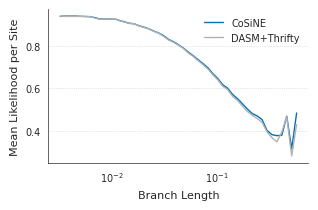

In [5]:
combined = pd.concat([
    # peint_df.assign(model='PEINT 150M'),
    # peint_650m_df.assign(model='PEINT 650M'),
    ctmc_df.assign(model='CoSiNE'),
    dasm_df.assign(model='DASM+Thrifty')
    # codon_df.assign(model='Codon Model'),
    # dasm_og_bl_df.assign(model='DASM Model'),
], ignore_index=True)
combined['likelihood_per_site'] = np.exp(combined['ll_per_site'])

order = ['CoSiNE', 'DASM+Thrifty']
palette = {'CoSiNE': "#0173B2", 'DASM+Thrifty': "#b2b2b2"}

# make a line plot of mean "ll_per_site" column by "branch_length" column
# we will need to bin the branch lengths since there are so many unique values
sns.set_theme(style='white')
plt.rcParams.update({
    'font.size': 8, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'lines.linewidth': 1.0, 'grid.linewidth': 0.5
})

# 2. Data Processing (Log-Binning)
df = combined[combined['branch_length'] > 0].copy()
bins = np.geomspace(df['branch_length'].min(), df['branch_length'].max(), 50)
df['bin'] = pd.cut(df['branch_length'], bins=bins)
# Map bins to their midpoints for plotting x-axis
df['x'] = df['bin'].apply(lambda b: b.mid).astype(float)
plot_data = df.groupby(['model', 'x'])['likelihood_per_site'].mean().reset_index()

# 3. Plotting
fig, ax = plt.subplots(figsize=(3.25, 2)) # ICML single column width
plt.subplots_adjust(left=0.15, bottom=0.18, right=0.95, top=0.95)

sns.lineplot(
    data=plot_data, x='x', y='likelihood_per_site', hue='model', 
    hue_order=order, palette=palette, ax=ax, legend=True
)

# 4. Formatting
ax.set_xscale('log')
ax.set_xlabel('Branch Length')
ax.set_ylabel('Mean Likelihood per Site')

# Ticks & Grid
ax.tick_params(width=0.5, length=2)
for spine in ax.spines.values(): spine.set_linewidth(0.5)
ax.grid(axis='y', linestyle=':', linewidth=0.5)
sns.despine(top=True, right=True)

# Legend cleanup
ax.legend(title=None, frameon=False)

# plt.savefig('figure_ppl_vs_bl.pdf', bbox_inches='tight')
plt.show()

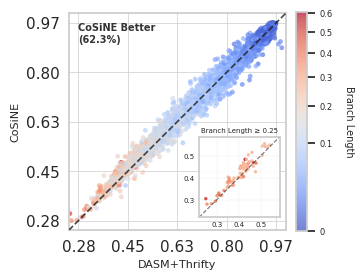

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

# --- PARAMETERS ---
cutoff = 0.25

# 1. Data Prep
df = combined.copy()
df['id'] = df.groupby('model').cumcount()
pivoted = df.pivot(index='id', columns='model', values='likelihood_per_site').dropna()
pivoted['bl'] = df.pivot(index='id', columns='model', values='branch_length').iloc[:, 0]

x_col, y_col = 'DASM+Thrifty', 'CoSiNE'
X, Y, C = pivoted[x_col], pivoted[y_col], pivoted['bl']

# 2. Stats
pct_win = 100 * (Y > X).mean()

# 3. Setup Plot
sns.set_theme(style='whitegrid', rc={'font.size': 8, 'axes.labelsize': 8, 'grid.linewidth': 0.5})
fig, ax = plt.subplots(figsize=(3.5, 3.0))

# 4. Smart Limits
all_data = np.concatenate([X, Y])
vmin, vmax = np.percentile(all_data, 0.01), np.percentile(all_data, 99.99)
padding = (vmax - vmin) * 0.05
lims = [vmin - padding, vmax + padding]

# 5. Main Scatter 
norm = mcolors.PowerNorm(gamma=0.5, vmin=C.min(), vmax=C.max())
sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm, 
                s=12, alpha=0.7, edgecolor='none', zorder=2)

# Diagonal Line
ax.plot([lims[0], lims[1]], [lims[0], lims[1]], 'k--', lw=1.2, alpha=0.8, zorder=3)

# 6. Inset: Zoom-in
axins = ax.inset_axes([0.60, 0.06, 0.37, 0.37]) 

# Filter subset
mask_long = C > cutoff
X_long, Y_long, C_long = X[mask_long], Y[mask_long], C[mask_long]

# Inset Scatter
axins.scatter(X_long, Y_long, c=C_long, cmap='coolwarm', norm=norm, 
              s=6, alpha=0.9, edgecolor='none')

# Inset Diagonal & Limits
l_min, l_max = min(X_long.min(), Y_long.min()), max(X_long.max(), Y_long.max())
l_pad = (l_max - l_min) * 0.1
axins.plot([l_min-l_pad, l_max+l_pad], [l_min-l_pad, l_max+l_pad], 'k--', lw=0.8, alpha=0.6)
axins.set_xlim(l_min - l_pad, l_max + l_pad)
axins.set_ylim(l_min - l_pad, l_max + l_pad)

# Inset Styling - TIGHTER TICKS
axins.set_title(f'Branch Length ≥ {cutoff}', fontsize=5, pad=3)
# pad=1 brings the labels closer to the axis
axins.tick_params(axis='both', which='major', labelsize=5, length=2, pad=1) 
axins.grid(True, linestyle=':', linewidth=0.3)
axins.set_facecolor((1, 1, 1, 0.9))

# 7. Main Formatting
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ticks = np.linspace(vmin, vmax, 5)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f'{t:.2f}' for t in ticks])
ax.set_yticklabels([f'{t:.2f}' for t in ticks])

# Add visible ticks to main axes (length=3 makes them visible but subtle)
ax.tick_params(axis='both', which='major', length=3, width=0.5)

ax.set_xlabel(f'{x_col}')
ax.set_ylabel(f'{y_col}')

# Annotation
ax.text(lims[0] + padding, lims[1] - padding, f'{y_col} Better\n({pct_win:.1f}%)', 
        ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)

# 8. Colorbar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Branch Length', rotation=270, labelpad=15, fontsize=7)
cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2g')) 
cbar.ax.tick_params(labelsize=6)

sns.despine(ax=ax, top=False, right=False)
plt.tight_layout()
plt.savefig('figure_parity_likelihood_final.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# whisker plot perplexity column. color by method and annotate mean above each box
fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=combined, x='model', y='ppl', order=order, palette=palette, ax=ax, showmeans=False)
ax.set_title('Perplexity Comparison Between Models')
ax.set_xlabel('')
ax.set_ylabel('Perplexity')
ax.set_yscale('log')

# compute means and annotate
means = combined.groupby('model')['ppl'].mean()
for i, m in enumerate(order):
    mean_val = means.loc[m]
    y = mean_val * 0.98
    ax.text(i, y, f"{mean_val:.3f}", ha='center', va='bottom', fontweight='bold')

plt.show()

/tmp/ipykernel_3162302/758342829.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)


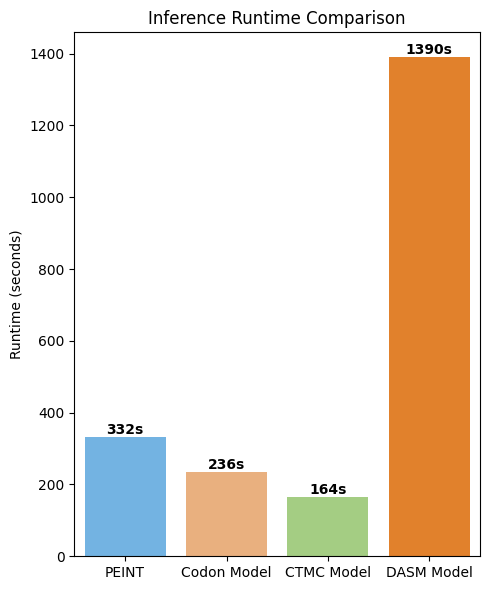

In [48]:
runtime_in_seconds = {
    "PEINT": 5*60+32,
    "Codon Model": 180+56,
    "CTMC Model": 120+44,
    "DASM Model": 1390
}
order = ['PEINT', 'Codon Model', 'CTMC Model', 'DASM Model']
palette = {'PEINT': "#60b6f4", 'Codon Model': "#fbaf6d", 'CTMC Model': "#a3d977", 'DASM Model': "#ff7f0e"}

# Create runtime comparison plot
runtime_df = pd.DataFrame(list(runtime_in_seconds.items()), columns=['model', 'runtime'])

fig, ax = plt.subplots(figsize=(5, 6))
sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Inference Runtime Comparison')

# Annotate bars with values
for i, m in enumerate(order):
    runtime_val = runtime_in_seconds[m]
    ax.text(i, runtime_val, f"{runtime_val}s", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Eval perplexity broken down by CDR and FR regions

In [7]:
import os
import numpy as np
from tqdm import tqdm
from typing import List

from Bio.Seq import Seq
from evo.antibody import compute_region_masks_batch
from evo.dataset import ComplexCherriesDataset
from evo.tensor import collate_list_of_dicts

/accounts/projects/yss/stephen.lu/peint-workspace/main/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [11]:
# populate this with the final data points
import pickle
final_data = []

# with open("results/inf_eval/final_data.pkl", "rb") as f:
#     final_data = pickle.load(f)

unique_methods = set([item["model"] for item in final_data])
print(unique_methods)

num_cpus = os.cpu_count()
print(f"Using {num_cpus} CPUs for mask computation.")

set()
Using 16 CPUs for mask computation.


In [12]:
def extract_sequences_from_dataset(dataset: ComplexCherriesDataset, translate: bool = False):
    all_seqs = [item[1] for item in dataset]    # List[[str, str]]
    if len(all_seqs[0]) == 2:
        hv_seqs, lt_seqs = zip(*all_seqs)
    else:
        hv_seqs, lt_seqs = [s[0] for s in all_seqs], []
    if translate:
        hv_seqs = [str(Seq(hv).translate()) for hv in tqdm(hv_seqs)]
        lt_seqs = [str(Seq(lt).translate()) for lt in tqdm(lt_seqs)]
    return hv_seqs, lt_seqs

def compute_masks(hv_seqs: List[str], lt_seqs: List[str], num_workers: int = 8):
    hv_masks, lt_masks = None, None
    if len(hv_seqs) > 0:
        hv_masks = compute_region_masks_batch(hv_seqs, num_workers=num_workers, scheme="imgt", show_progress=True, raise_on_error=True)  # List[Dict[str, np.ndarray]]
        hv_masks = collate_list_of_dicts(hv_masks, hv_masks[0].keys(), constant_value=False)    # Dict[str, np.ndarray]
    if len(lt_seqs) > 0:
        lt_masks = compute_region_masks_batch(lt_seqs, num_workers=num_workers, scheme="imgt", show_progress=True, raise_on_error=True)  # List[Dict[str, np.ndarray]]
        lt_masks = collate_list_of_dicts(lt_masks, lt_masks[0].keys(), constant_value=False)    # Dict[str, np.ndarray]
    return hv_masks, lt_masks

def add_ppls_to_final_data_chain(masks, nlls, szs, method: str, chain: str = "heavy", bls=None):
    # 1. Add Region-Specific Data
    for region in masks.keys():
        # avoid division by zero
        region_len = np.nansum(masks[region], -1).clip(min=1, max=1e9)
        reg_mean_nll = (nlls * masks[region]).sum(-1) / region_len
        
        # We explicitly store 'sample_id': i
        final_data.extend([
            {
                "sample_id": i,  # <--- CRITICAL FIX
                "chain": chain, 
                "region": region, 
                "model": method, 
                "ppl": ppl, 
                "branch_length": bls[i] if bls is not None else None
            }
            for i, ppl in enumerate(np.exp(reg_mean_nll).tolist())
        ])

    # # 2. Add Total Data (Outside the loop!)
    # tot_mean_nll = nlls.sum(-1) / szs
    # final_data.extend([
    #     {
    #         "sample_id": i, 
    #         "chain": chain, 
    #         "region": "total", 
    #         "model": method, 
    #         "ppl": ppl, 
    #         "branch_length": bls[i] if bls is not None else None
    #     }
    #     for i, ppl in enumerate(np.exp(tot_mean_nll).tolist())
    # ])
    
    return final_data

def add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method: str, bls=None):
    # check if method is already in the final_data
    unique_methods = set([item["model"] for item in final_data])
    if method in unique_methods:
        print(f"Method {method} already in final_data, skipping...")
        return
    if hv_masks is not None and hv_nlls is not None:
        add_ppls_to_final_data_chain(hv_masks, hv_nlls, hv_szs, method=method, bls=bls, chain="heavy")
    if lt_masks is not None and lt_nlls is not None:
        add_ppls_to_final_data_chain(lt_masks, lt_nlls, lt_szs, method=method, bls=bls, chain="light")

In [13]:
# calculate regions for ctmc inference dataset
data_dir = "/scratch/users/stephen.lu/projects/protevo/paper/ctmc_eval"
ctmc_nlls = np.load(f"{data_dir}/ctmc_rodriguezCC.npz")  # (num_samples, seq_len)
hv_nlls, lt_nlls, hv_szs, lt_szs, bls = ctmc_nlls["hv_nlls"], ctmc_nlls["lt_nlls"], ctmc_nlls["hv_szs"], ctmc_nlls["lt_szs"], ctmc_nlls["bls"]
bls = bls[:, 0]
ctmc_hv_nlls = hv_nlls

# check if method is already in the final_data
if "PhyloESM" in unique_methods:
    print(f"Method PhyloESM already in final_data, skipping...")
else:
    datafile = "/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/edges/test/v1rodriguezCC.txt"
    dataset = ComplexCherriesDataset(data_file=datafile, min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=num_cpus)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, bls=bls, method="PhyloESM")

Computing masks: 100%|██████████| 33834/33834 [01:21<00:00, 412.81it/s]


In [10]:
# calculate regions for peint inference dataset
peint_nlls = np.load("../results/inf_eval/peint_nlls_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = peint_nlls['hv_nlls'], peint_nlls['lt_nlls'], peint_nlls['hv_szs'], peint_nlls['lt_szs']

if "PEINT" in unique_methods:
    print(f"Method PEINT already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="../data/wyatt/subs/edges_joint/aa/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="PEINT")

Method PEINT already in final_data, skipping...


In [18]:
# calculate regions for peint inference dataset
peint_nlls = np.load("results/inf_eval/peint_650m_nlls_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = peint_nlls['hv_nlls'], peint_nlls['lt_nlls'], peint_nlls['hv_szs'], peint_nlls['lt_szs']

if "PEINT 650M" in unique_methods:
    print(f"Method PEINT 650M already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="data/wyatt/subs/edges_joint/aa/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="PEINT 650M")

Computing masks:   0%|                                                                               | 0/60403 [00:00<?, ?it/s]

Computing masks: 100%|██████████████████████████████████████████████████████████████████| 60403/60403 [03:26<00:00, 292.74it/s]
/tmp/ipykernel_998461/1305127825.py:30: RuntimeWarning: invalid value encountered in divide
  hv_reg_mean_nll = (hv_nlls * hv_masks[region]).sum(-1) / hv_masks[region].sum(-1)


In [11]:
# calculate regions for codon inference dataset
codon_nlls = np.load("../results/inf_eval/codon_nlls_d4.npz")
# codon_nlls = np.load("../results/inf_eval/codon_nlls_bw_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = codon_nlls['hv_nlls'], codon_nlls['lt_nlls'], codon_nlls['hv_szs'], codon_nlls['lt_szs']

if "Codon" in unique_methods:
    print(f"Method Codon already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="../data/wyatt/subs/edges_joint/nt/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=True)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="Codon")

Method Codon already in final_data, skipping...


In [14]:
# calculate regions for dasm inference dataset
data_dir = "/scratch/users/stephen.lu/projects/protevo/paper/ctmc_eval"
dasm_nlls = np.load(f"{data_dir}/dasm+thrifty+opt-bl_ll_rodriguezCC.npz")  # (num_samples, seq_len)
hv_nlls, lt_nlls, hv_szs, lt_szs = dasm_nlls['hv_nlls'], dasm_nlls['lt_nlls'], dasm_nlls['hv_szs'], dasm_nlls['lt_szs']
dasm_hv_nlls = hv_nlls

if "DASM" in unique_methods:
    print(f"Method DASM already in final_data, skipping...")
else:
    # dataset = pd.read_csv("../data/wyatt/subs/dasm_eval_d4.csv.gz", compression='gzip')
    # dataset = pd.read_csv("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/dasm/processed/rodriguez-igh.csv")
    # hv_seqs = dataset['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
    # # lt_seqs = dataset['child_light'].progress_apply(lambda x: str(Seq(x).translate()))
    # assert all([len(hv) == hvs for hv, hvs in zip(hv_seqs, hv_szs)])
    # # assert all([len(lt) == lts for lt, lts in zip(lt_seqs, lt_szs)])
    # hv_masks, lt_masks = compute_masks(hv_seqs, [], num_workers=num_cpus)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, bls=bls, method="DASM+Thrifty")

### Plot perplexity distributions for each region and color by method

In [15]:
# create a dataframe for plotting
final_df = pd.DataFrame(final_data)
# models_to_plot = ['PhyloESM', 'DASM+Thrifty']
# final_df = final_df[final_df['model'].isin(models_to_plot)]
final_df['likelihood_per_site'] = 1 / final_df['ppl']
final_df = final_df[final_df['region'] != 'total']
final_df.to_csv("/scratch/users/stephen.lu/projects/protevo/paper/ctmc_eval/rodriguezCC_ppl_by_region_all_models.csv", index=False)

In [19]:
final_df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/paper/ctmc_eval/rodriguezCC_ppl_by_region_all_models.csv")
print(final_df.columns)
print(final_df.shape)

# rename PhyloESM to CoSiNE
final_df.loc[final_df['model'] == 'PhyloESM', 'model'] = 'CoSiNE'

Index(['sample_id', 'chain', 'region', 'model', 'ppl', 'branch_length',
       'likelihood_per_site'],
      dtype='object')
(609012, 7)


In [20]:
# Robust Pivot
# We align on Sample ID, Chain, AND Region
pivoted_df = final_df.pivot(
    index=['sample_id', 'chain'],  # Keep chain in the index!
    columns=['model', 'region'], 
    values=['ppl', 'branch_length'] # You can grab branch length here too
)

# Flatten columns naturally
pivoted_df.columns = [f'{val}_{model}_{reg}' for val, model, reg in pivoted_df.columns]
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.dropna()

# Now you have a 'chain' column in your final df!
# print(pivoted_df.head())
print(pivoted_df.shape)

(25955, 38)


/tmp/ipykernel_3894830/3577571057.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


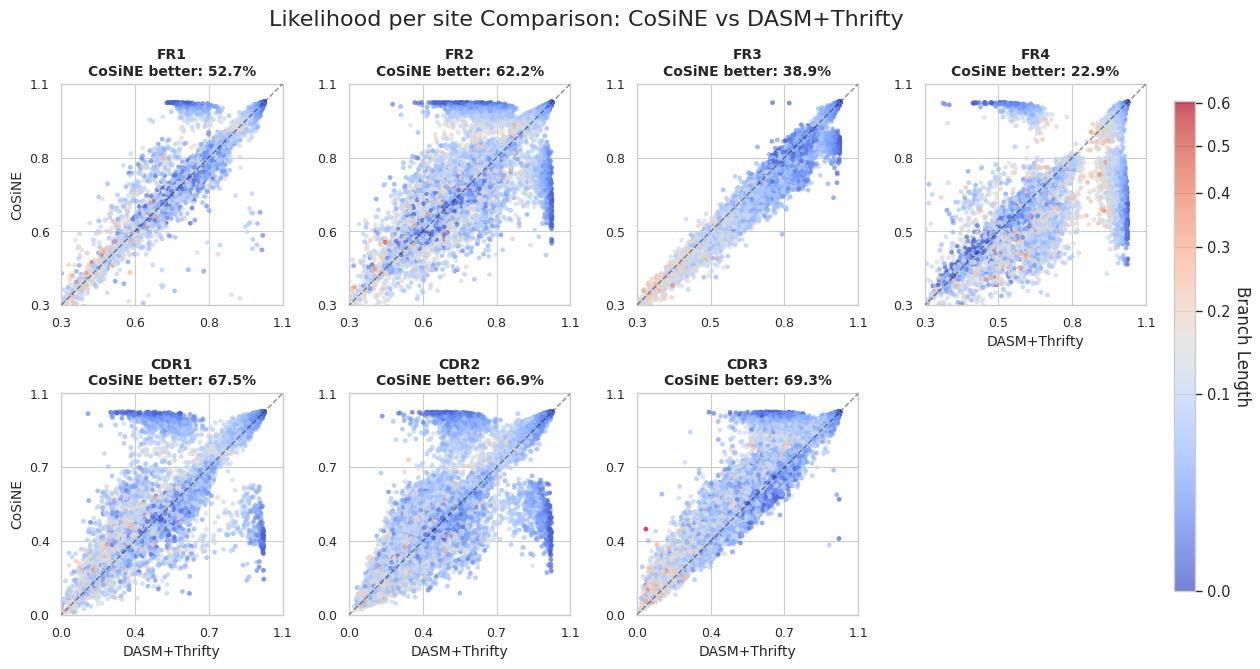

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

# --- 1. Setup & Style ---
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'grid.linewidth': 0.5})

# !!! USER CONFIGURATION !!!
# Ensure these match the strings in your 'model' column exactly
x_col = 'DASM+Thrifty' 
y_col = 'CoSiNE'

regions_fr = ['FR1', 'FR2', 'FR3', 'FR4']
regions_cdr = ['CDR1', 'CDR2', 'CDR3']
all_regions = regions_fr + regions_cdr

# --- 2. Data Preparation Function ---
def get_region_data(df, region, model_x, model_y):
    """
    Filters data for a region, aligns rows using cumcount, 
    and pivots to get paired (X, Y) coordinates.
    """
    # Filter by region
    subset = df[df['region'] == region].copy()
    
    # CRITICAL STEP: Create a synthetic ID to align the two models
    # This assumes the rows for Model A and Model B are in the same relative order
    subset['row_id'] = subset.groupby('model').cumcount()
    
    # Pivot PPL (Perplexity)
    pivoted = subset.pivot(index='row_id', columns='model', values='likelihood_per_site')
    
    # Pivot Branch Length
    # We grab branch lengths for all models, then select one (they should be identical)
    bl_pivot = subset.pivot(index='row_id', columns='model', values='branch_length')
    
    # Ensure both models exist in this region
    if model_x not in pivoted.columns or model_y not in pivoted.columns:
        return None, None, None

    # Clean up: Select columns and drop missing pairs
    # We take branch length from model_y, but it could be model_x (should be same tree)
    data = pd.DataFrame({
        'X': pivoted[model_x],
        'Y': pivoted[model_y],
        'BL': bl_pivot[model_y] 
    }).dropna()
    
    return data['X'], data['Y'], data['BL']

# --- 3. Figure Layout ---
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3)

axes = []
# Row 0: Frameworks
for i in range(4):
    axes.append(fig.add_subplot(gs[0, i]))
# Row 1: CDRs (centered/left aligned)
for i in range(3):
    axes.append(fig.add_subplot(gs[1, i]))

# Global Branch Length Normalization
# Compute global min/max so the color scale is consistent across all subplots
global_bl_min = final_df['branch_length'].min()
global_bl_max = final_df['branch_length'].max()
# Use PowerNorm to make variation in small branch lengths more visible
norm = mcolors.PowerNorm(gamma=0.5, vmin=global_bl_min, vmax=global_bl_max)

# --- 4. Plotting Loop ---
for i, region in enumerate(all_regions):
    ax = axes[i]
    
    # Get Data
    X, Y, C = get_region_data(final_df, region, x_col, y_col)
    
    # Handle empty/missing data gracefully
    if X is None or len(X) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(region, fontweight='bold')
        continue

    # Stats: Calculate win % for Y-axis model
    pct_win = 100 * (Y > X).mean() # Note: LOWER perplexity is better
    
    # Dynamic Limits (1st to 99th percentile to ignore extreme outliers)
    all_vals = np.concatenate([X, Y])
    vmin, vmax = np.percentile(all_vals, 0.5), np.percentile(all_vals, 99.5)
    padding = (vmax - vmin) * 0.1
    lims = [max(0, vmin - padding), vmax + padding]
    
    # Scatter Plot
    sc = ax.scatter(X, Y, c=C, cmap='coolwarm', norm=norm, 
                    s=12, alpha=0.7, edgecolor='none', zorder=2)
    
    # Diagonal Line (Identity)
    ax.plot([0, 1000], [0, 1000], 'k--', lw=1.0, alpha=0.5, zorder=3)
    
    # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{region}\n{y_col} better: {pct_win:.1f}%", fontweight='bold', fontsize=10)
    
    # Clean Ticks
    ticks = np.linspace(lims[0], lims[1], 4)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([f'{t:.1f}' for t in ticks], fontsize=9)
    ax.set_yticklabels([f'{t:.1f}' for t in ticks], fontsize=9)
    
    # Axis Labels (Only on outer edges)
    is_bottom = (i >= 4) or (i == 3) # last in first row or any in second
    is_left = (i == 0 or i == 4)
    
    if is_bottom:
        ax.set_xlabel(x_col, fontsize=10)
    if is_left:
        ax.set_ylabel(y_col, fontsize=10)
        
    # Annotation (Win %)
    # Logic: If Y < X, Y is "better" (lower perplexity).
    # ax.text(0.05, 0.95, f'{y_col} better:\n{pct_win:.1f}%', 
    #         ha='left', va='top', transform=ax.transAxes,
    #         fontsize=9, fontweight='bold', color='#333',
    #         bbox=dict(facecolor='white', alpha=0., edgecolor='none', pad=2))

# --- 5. Shared Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Branch Length', rotation=270, labelpad=15, fontsize=12)

plt.suptitle(f'Likelihood per site Comparison: {y_col} vs {x_col}', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig(f'{x_col}_vs_{y_col}_rodriguezCC.pdf', bbox_inches='tight')
plt.show()

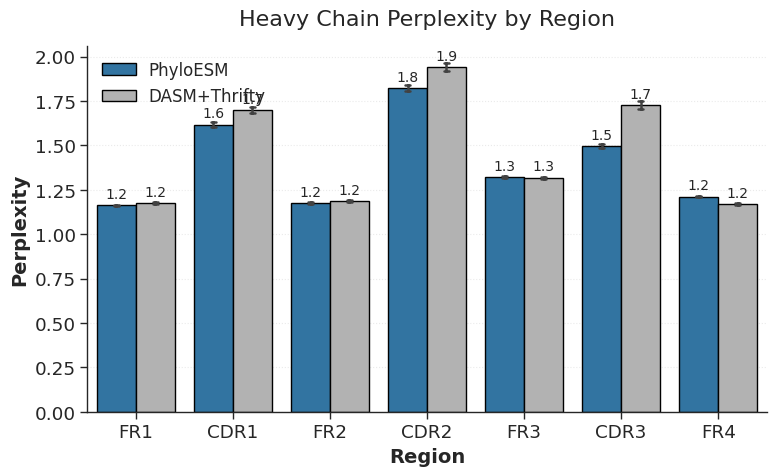

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- 1. Setup & Styling for ICML ---
sns.set_context("paper", font_scale=1.5) 
sns.set_style("ticks")

# Define Region Order and Palette
keys_to_use = ['FR1', 'CDR1', 'FR2', 'CDR2', 'FR3', 'CDR3', 'FR4']

palette = {
    'PhyloESM': "#1f77b4",       # Standard Blue
    'DASM+Thrifty': "#b2b2b2",   # Standard Gray
    # Include others if they are in your data
    'Codon': "#fbaf6d", 
    'Codon RV': "#ef6dfb", 
    'PEINT': "#60b6f4", 
    'PEINT 650M': "#1f77b4", 
    'DASM': "#ff7f0e", 
    'CTMC': "#a3d977"
}

# --- 2. Data Filtering ---
# Filter for Models and Regions
df_plot = final_df[
    (final_df['region'].isin(keys_to_use)) & 
    (final_df['model'].isin(palette.keys()))
].copy()

# Filter for Heavy Chain if the column exists
if 'chain' in df_plot.columns:
    df_plot = df_plot[df_plot['chain'] == 'heavy']

# --- 3. Plotting ---
plt.figure(figsize=(8, 5))
ax = plt.gca()

# Bar Plot with Interquartile Range
sns.barplot(
    data=df_plot,
    x='region',
    y='ppl',
    hue='model',
    order=keys_to_use,
    palette=palette,
    
    capsize=0.1,      # Caps on error bars
    edgecolor='black',# Sharp edges
    linewidth=1.0,
    ax=ax
)

# Log Scale
# ax.set_yscale('log')

# --- 4. Formatting ---
ax.set_ylabel('Perplexity', fontsize=14, fontweight='bold')
ax.set_xlabel('Region', fontsize=14, fontweight='bold')
ax.set_title('Heavy Chain Perplexity by Region', fontsize=16, pad=15)

# Clean Spines
sns.despine()

# Grid
ax.yaxis.grid(True, linestyle=':', alpha=0.4)

# Legend (Inside if space permits, or outside top-right)
# Locating it 'upper left' usually works well for log-scale plots where bars vary
ax.legend(title=None, frameon=False, fontsize=12, loc='upper left')

# Add numeric labels (Mean) carefully
for container in ax.containers:
    if isinstance(container[0], plt.Rectangle):
        # formatted to 1 decimal place for cleanliness
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
# plt.savefig('figure_heavy_chain_perplexity.pdf', bbox_inches='tight')
plt.show()

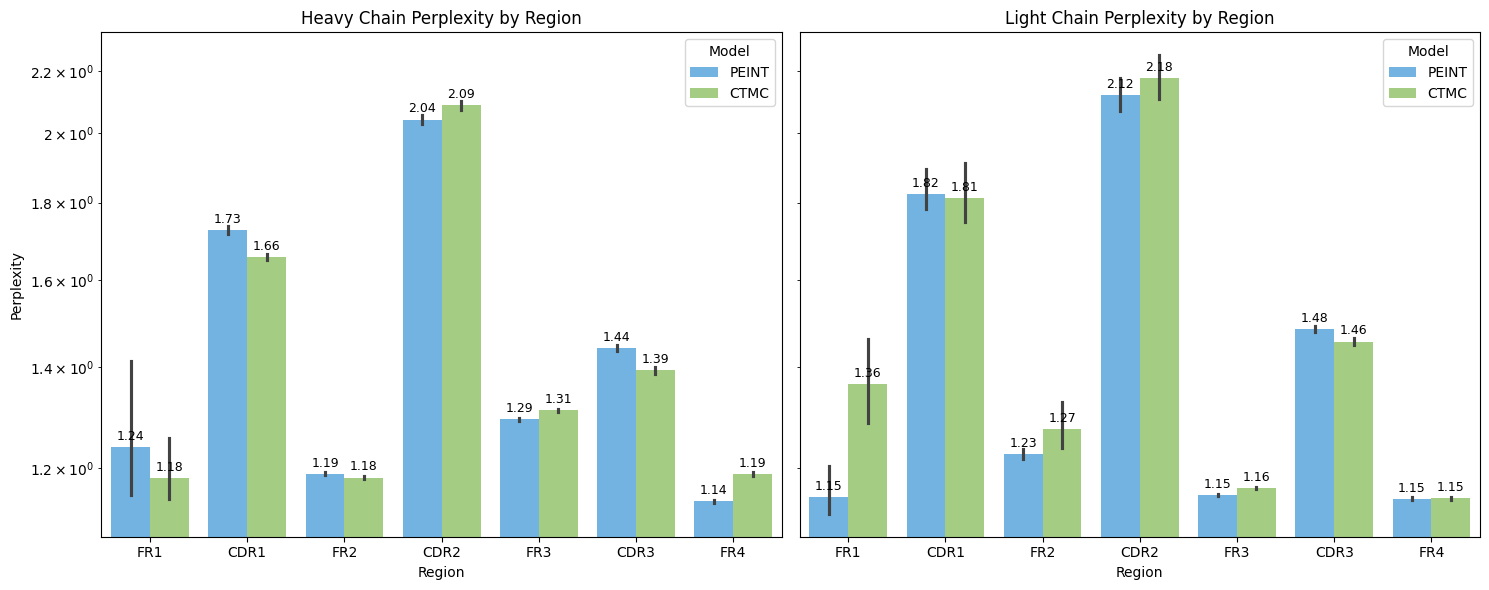

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
sns.barplot(
    data=loc_final_df[(loc_final_df['chain'] == 'heavy') & (loc_final_df['region'].isin(keys_to_use))],
    x='region',
    y='ppl',
    hue='model',
    palette=palette,
    errorbar=('ci', 95),
    ax=ax[0]
)
sns.barplot(
    data=loc_final_df[(loc_final_df['chain'] == 'light') & (loc_final_df['region'].isin(keys_to_use))],
    x='region',
    y='ppl',
    hue='model',
    palette=palette,
    errorbar=('ci', 95),
    ax=ax[1]
)
ax[0].set_title('Heavy Chain Perplexity by Region')
ax[0].set_xlabel('Region')
ax[0].set_ylabel('Perplexity')
ax[1].set_title('Light Chain Perplexity by Region')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].legend(title='Model')
ax[1].legend(title='Model')

# Add mean values as text on each bar
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()